# Creating ReAct WorkFLow 

In [1]:
import os
from dotenv import load_dotenv

# Load variables from the .env file into the environment
load_dotenv()
# os.environ['LANGCHAIN_TRACING_V2'] = 'true'
# os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
# os.environ['LANGCHAIN_PROJECT'] = 'Sub-Workflows'
# os.environ['LANGCHAIN_API_KEY'] = os.getenv("LANGCHAIN_API_KEY")
os.environ['GROQ_API_KEY'] = os.getenv("GROQQ_API_KEY")
os.environ['TAVILY_API_KEY'] = os.getenv("TAVILY_API_KEY")

In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_groq import ChatGroq
mytool = TavilySearchResults(max_results=3)


In [3]:
search_li=mytool.invoke("what is langgraph")

In [4]:
context_str=""
for idx,item in enumerate(search_li):
    context_str+=f"\ncontext-{idx+1} :\n"+  (item.get('content'))

print(context_str)


context-1 :
LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. By managing the flow of data and the sequence of operations, LangGraph allows developers to focus on the high-level logic of their applications rather than the intricacies of agent coordination. Whether you need a chatbot that can handle various types of user requests or a multi-agent system that performs complex tasks, LangGraph provides the tools to build exactly what you need. LangGraph significantly simplifies the development of complex LLM applications by providing a structured framework for managing state and coordinating agent interactions.
context-2 :
In this article, we’ll introduce LangGraph, walk you through its basic concepts, and share some insights and common points of confusion for beginners. While LangChain allows you to define chains of computation (Directed Acyclic G

In [5]:
from langchain_core.prompts import ChatPromptTemplate

prompt_template = ChatPromptTemplate([
("system", """ou are a helpful assistant. Your primary task is to answer the query provided to you. You will be given multiple pieces of context related to the query. Based on all the provided context, your response should be formulated. If any context is irrelevant to the query, simply disregard it and focus on the relevant information. Your answer must strictly be derived from the valid context, which forms the "ground truth" for your response. Do not provide any extra information that is not included in the given context. Your response should strictly adhere to the information in the context without adding unrelated details.
Query: '{query}'"""),
("human", "{contexts}")])
input_template=prompt_template.invoke({"query":"what is langgraph","contexts":context_str})

In [6]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
answer = llm.invoke(input_template).content
answer

'LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents in a structured and efficient manner. It allows developers to build complex LLM applications by managing the flow of data and the sequence of operations, and enables the creation of stateful, multi-actor applications utilizing LLMs. LangGraph introduces the ability to add cycles to Directed Acyclic Graphs (DAGs), enabling more complex, agent-like behaviors where an LLM can be called in a loop to determine the next action. It simplifies the development of complex LLM applications by providing a structured framework for managing state and coordinating agent interactions.'

## Creating Basic workflow which will be used as a Tool

In [7]:
import operator
from operator import add
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langgraph.graph import MessagesState,StateGraph
from typing import List, Optional, Annotated, Sequence

from typing import Dict, TypedDict, Optional, Callable
from langgraph.graph import StateGraph, END, START

In [8]:
class Mainstate(TypedDict):
    query : str
    context : str
    answer : str

def search_query(state:Mainstate):
    query = state['query']
    search_li=mytool.invoke(query)
    context_str=""
    for idx,item in enumerate(search_li):
        context_str+=f"\ncontext-{idx+1} :\n"+  (item.get('content'))
    return {"context":context_str}

def genrate_answer(state:Mainstate):
    query = state['query']
    contexts = state['context']

    prompt_template = ChatPromptTemplate([
    ("system", """ou are a helpful assistant. Your primary task is to answer the query provided to you. You will be given multiple pieces of context related to the query. Based on all the provided context, your response should be formulated. If any context is irrelevant to the query, simply disregard it and focus on the relevant information. Your answer must strictly be derived from the valid context, which forms the "ground truth" for your response. Do not provide any extra information that is not included in the given context. Your response should strictly adhere to the information in the context without adding unrelated details.
    Query: '{query}'"""),
    ("human", "{contexts}")])

    input_template=prompt_template.invoke({"query":query,"contexts":contexts})
    answer = llm.invoke(input_template).content

    return {"answer" : answer}

workflow=StateGraph(Mainstate)
workflow.add_node("search_query",search_query)
workflow.add_node("genrate_answer",genrate_answer)

workflow.add_edge(START,"search_query")
workflow.add_edge("search_query","genrate_answer")
workflow.add_edge("genrate_answer",END)

main_app = workflow.compile()


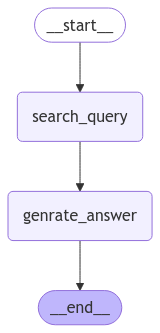

In [9]:
main_app

In [10]:
app_ans=main_app.invoke({"query":"what is langchain"})

In [11]:
app_ans

{'query': 'what is langchain',
 'context': "\ncontext-1 :\nLangChain is an open source framework that enables software developers working with artificial intelligence (AI) and its machine learning subset to combine large language models with other external components to develop LLM-powered applications. LangChain is a framework that simplifies the process of creating generative AI application interfaces. LangChain includes prompt template modules that enable developers to create structured prompts for LLMs. These templates can incorporate examples and specify output formats, facilitating smoother interactions and more accurate responses from the models. The LangChain framework helps developers create LLM-powered applications by offering tools that build intricate workflows and integrate different components. Use LangChain and vector search on Amazon DocumentDB to build a generative AI ...\ncontext-2 :\nLangChain is an open source framework for building applications based on large langu

In [12]:
app_ans.get('answer')

'LangChain is an open-source framework that enables software developers to build applications based on large language models (LLMs) by combining them with external components. It simplifies the process of creating generative AI application interfaces and provides tools to connect language models with external data sources, allowing developers to create structured prompts and customize existing templates for various applications, such as chatbots and few-shot learning.'

## crating workflow which will take Another Workflow as a Tool

In [ ]:
from langchain_core.tools import tool

@tool
def resercher(query: str) -> str:
    """
    Performs an internet research based on a descriptive query and returns a detailed answer.

    This tool leverages the main application's search functionality to retrieve comprehensive 
    information from the internet. It is important to pass a full, well-formed question rather than 
    a single keyword. For instance, instead of just "langgraph", you should use a query like 
    "What is langgraph?" to obtain a complete and accurate answer.

    Parameters:
        query (str): A descriptive and complete query string to be researched on the internet. 
                     Use full questions for best results.

    Returns:
        str: The detailed answer retrieved from the internet based on the provided query.
    """
    app_ans = main_app.invoke({"query": query})
    return app_ans.get('answer')


In [14]:
resercher.name

'resercher'

In [15]:
tools=[resercher]

In [ ]:
from langchain_core.messages import SystemMessage

class State(TypedDict):
    messages: Annotated[list, add_messages]


llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    system_msg=[SystemMessage(content="You are a helpull assistent and you also have access of resercher tool where you have to pass a proper query like you search on internet. your main taske is to answer the humen message if you got enough information to answer humen question then response and donot call tool unnecessary.")]
    return {"messages": [llm_with_tools.invoke( system_msg + state["messages"])]}



In [17]:
import json

from langchain_core.messages import ToolMessage

def route_tools(
    state: State,
):
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END



class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}


tool_node = BasicToolNode(tools=tools)

In [18]:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", tool_node)


# The `tools_condition` function returns "tools" if the chatbot asks to use a tool, and "END" if
# it is fine directly responding. This conditional routing defines the main agent loop.
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node
    # It defaults to the identity function, but if you
    # want to use a node named something else apart from "tools",
    # You can update the value of the dictionary to something else
    # e.g., "tools": "my_tools"
    {"tools": "tools", END: END},
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

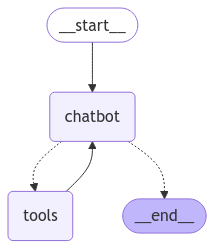

In [19]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
from langchain_core.messages import HumanMessage

inputs = {"messages": [HumanMessage(content="What is langgraph")]}
for chunk in graph.stream(
    inputs, stream_mode="values"
):
    chunk["messages"][-1].pretty_print()



================================ Human Message =================================

What is langgraph
================================== Ai Message ==================================
Tool Calls:
  resercher (call_mhyy)
 Call ID: call_mhyy
  Args:
    query: What is langgraph?
================================= Tool Message =================================
Name: resercher

"LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents in a structured and efficient manner. It allows developers to manage the flow of data and sequence of operations, simplifying the development of complex LLM applications by providing a structured framework for managing state and coordinating agent interactions. LangGraph introduces the ability to add cycles to Directed Acyclic Graphs (DAGs), enabling more complex, agent-like behaviors, and is a versatile tool for building complex, stateful applications with LLMs. It enables the c

KeyboardInterrupt: 

In [ ]:
resercher.run("what is large language model")

'A large language model (LLM) is a type of artificial intelligence (AI) program that can recognize, comprehend, and generate human language text. It is a machine learning model designed for natural language processing tasks, such as language generation, and is trained on huge sets of data using deep learning, specifically a type of neural network called a transformer model. LLMs can perform various language tasks, including answering questions, summarizing text, translating between languages, and writing content.'